In [1]:
import pandas as pd
import numpy as np
from autogluon.tabular import TabularDataset, TabularPredictor
import seaborn as sns
import matplotlib.pyplot as plt

/home/ai/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
odroid1 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid1_firefox_carbonyl7.csv")
odroid2 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid2_firefox_carbonyl7.csv")
odroid3 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid3_firefox_carbonyl7.csv")
odroid4 = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/odroid4_firefox_carbonyl7.csv")

In [3]:
rpi4a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-4a_chrome_carbonyl7.csv")
rpi8a = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8a_chrome_carbonyl7.csv")
rpi8b = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8b_carbonyl_onscreen.csv")
rpi8c = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi_8c_carbonyl_onscreen.csv")
rpi8d = pd.read_csv("https://raw.githubusercontent.com/brite3001/drawnapart/master/carbonyl/vec_7/rpi-8d_chrome_carbonyl7.csv")

In [4]:
df = pd.concat([odroid1[:1000], odroid2[:1000], odroid3[:1000], odroid4[:1000], rpi4a[:1000], rpi8a[:1000], rpi8b[:1000], rpi8c[:1000], rpi8d[:1000]])
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
df.head()

,label,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
0,odroid4,87.3,89.9,85.4,83.7,84.0,83.3,83.6
1,odroid4,87.7,85.4,84.6,83.5,83.2,83.5,83.0
2,rpi-8d,62.2,61.5,60.6,60.0,59.6,59.9,59.7
3,rpi-8d,62.6,60.9,60.1,59.6,59.1,59.2,59.6
4,odroid3,84.2,82.5,82.2,81.0,80.7,80.4,80.6


In [6]:
len(df)

9000

In [7]:
stats_df = pd.DataFrame(columns=['data_amount', 'precision', 'recall', 'f1'])
best_model = {}
best_features = {}

for i in range(1000, 9000, 1000):
    train_data = df.head(i)
    test_data = df.tail(1000)

    predictor = TabularPredictor(label='label').fit(train_data, num_gpus=1, presets='good_quality')
    y_pred = predictor.predict(test_data)
    y_pred_proba = predictor.predict_proba(test_data)
    results = predictor.evaluate(test_data, detailed_report=True)['classification_report']['weighted avg']

    new_row = {'data_amount': i, 'precision': results['precision'], 'recall':results['recall'], 'f1':results['f1-score']}
    stats_df.loc[len(stats_df)] = new_row

    model_leaderboard = predictor.leaderboard(test_data)
    # Which models came in the top three on the leaderboard most often?
    if model_leaderboard.loc[0]['model'] not in best_model:
        best_model[model_leaderboard.loc[0]['model']] = 1
    else:
        best_model[model_leaderboard.loc[0]['model']] += 1

    if model_leaderboard.loc[1]['model'] not in best_model:
        best_model[model_leaderboard.loc[1]['model']] = 1
    else:
        best_model[model_leaderboard.loc[1]['model']] += 1

    if model_leaderboard.loc[2]['model'] not in best_model:
        best_model[model_leaderboard.loc[2]['model']] = 1
    else:
        best_model[model_leaderboard.loc[2]['model']] += 1


    feature_importance = predictor.feature_importance(test_data)
    # Which features has the highest importance most often?
    if feature_importance.index[0] not in best_features:
        best_features[feature_importance.index[0]] = 1
    else:
        best_features[feature_importance.index[0]] += 1

    if feature_importance.index[1] not in best_features:
        best_features[feature_importance.index[1]] = 1
    else:
        best_features[feature_importance.index[1]] += 1

    if feature_importance.index[2] not in best_features:
        best_features[feature_importance.index[2]] = 1
    else:
        best_features[feature_importance.index[2]] += 1

No path specified. Models will be saved in: "AutogluonModels/ag-20240910_075216"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.11.9
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Debian 6.1.99-1 (2024-07-15)
CPU Count:          12
Memory Avail:       11.10 GB / 15.86 GB (70.0%)
Disk Space Avail:   17.06 GB / 96.93 GB (17.6%)
Presets specified: ['good_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
DyStack is enab

(_ray_fit pid=57023) [1000]	valid_set's multi_error: 0.288288


(_dystack pid=55608) 	0.7218	 = Validation score   (accuracy)
(_dystack pid=55608) 	0.54s	 = Training   runtime
(_dystack pid=55608) 	0.03s	 = Validation runtime
(_dystack pid=55608) Fitting model: LightGBM_BAG_L1 ... Training model for up to 589.05s of the 888.06s of remaining time.
(_dystack pid=55608) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (8 workers, per: cpus=1, gpus=0, memory=0.02%)
(_dystack pid=55608) 	0.6993	 = Validation score   (accuracy)
(_dystack pid=55608) 	0.7s	 = Training   runtime
(_dystack pid=55608) 	0.03s	 = Validation runtime
(_dystack pid=55608) Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 587.57s of the 886.59s of remaining time.
(_dystack pid=55608) 	0.6869	 = Validation score   (accuracy)
(_dystack pid=55608) 	0.52s	 = Training   runtime
(_dystack pid=55608) 	0.04s	 = Validation runtime
(_dystack pid=55608) Fitting model: RandomForestEntr_BAG_L1 ... Training model for up to 586.92s of the 885

In [8]:
stats_df

,data_amount,precision,recall,f1
0,1000,0.703059,0.709,0.700134
1,2000,0.720354,0.727,0.713133
2,3000,0.717366,0.721,0.713874
3,4000,0.719845,0.725,0.709471
4,5000,0.715351,0.723,0.710379
5,6000,0.724211,0.730,0.717524
6,7000,0.716607,0.727,0.712628
7,8000,0.714452,0.726,0.711462


<Axes: xlabel='data_amount', ylabel='value'>

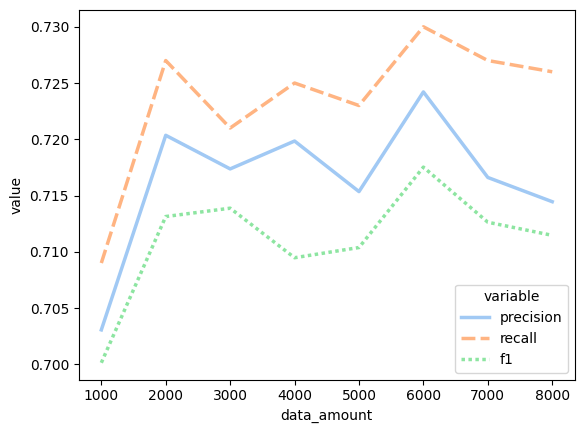

In [9]:
sns.lineplot(data=pd.melt(stats_df, ['data_amount']), x='data_amount', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

In [10]:
best_model

{'ExtraTreesGini_BAG_L1_FULL': 2,
 'ExtraTreesGini_BAG_L1': 2,
 'CatBoost_BAG_L2_FULL': 1,
 'ExtraTreesEntr_BAG_L1_FULL': 2,
 'ExtraTreesEntr_BAG_L1': 2,
 'ExtraTreesGini_BAG_L2_FULL': 2,
 'CatBoost_BAG_L1_FULL': 3,
 'WeightedEnsemble_L2_FULL': 1,
 'LightGBMLarge_BAG_L2_FULL': 1,
 'NeuralNetTorch_BAG_L2_FULL': 1,
 'LightGBM_BAG_L2_FULL': 1,
 'XGBoost_BAG_L2_FULL': 1,
 'ExtraTreesEntr_BAG_L2_FULL': 1,
 'LightGBMXT_BAG_L2_FULL': 1,
 'RandomForestEntr_BAG_L1_FULL': 1,
 'RandomForestEntr_BAG_L1': 1,
 'RandomForestGini_BAG_L1_FULL': 1}

([<matplotlib.patches.Wedge at 0x7f8b6c356910>,
 [Text(1.062518406696673, 0.28470095790278555, 'ExtraTreesGini_BAG_L1_FULL'),
  Text(0.7778174410990706, 0.7778174775113337, 'ExtraTreesGini_BAG_L1'),
  Text(0.42095173992041257, 1.016267500542046, 'CatBoost_BAG_L2_FULL'),
  Text(-5.149471629032507e-08, 1.0999999999999988, 'ExtraTreesEntr_BAG_L1_FULL'),
  Text(-0.5500000594609755, 0.9526279098330699, 'ExtraTreesEntr_BAG_L1'),
  Text(-0.9526279870751434, 0.5499999256737774, 'ExtraTreesGini_BAG_L2_FULL'),
  Text(-1.0905893351886038, -0.14357890504137136, 'CatBoost_BAG_L1_FULL'),
  Text(-0.8726886142366942, -0.6696376502121417, 'WeightedEnsemble_L2_FULL'),
  Text(-0.6696374867981205, -0.8726887396286818, 'LightGBMLarge_BAG_L2_FULL'),
  Text(-0.42095166855803917, -1.016267530101303, 'NeuralNetTorch_BAG_L2_FULL'),
  Text(-0.14357868806114077, -1.0905893637545903, 'LightGBM_BAG_L2_FULL'),
  Text(0.14357894333199936, -1.0905893301475431, 'XGBoost_BAG_L2_FULL'),
  Text(0.42095190643260955, -1.016

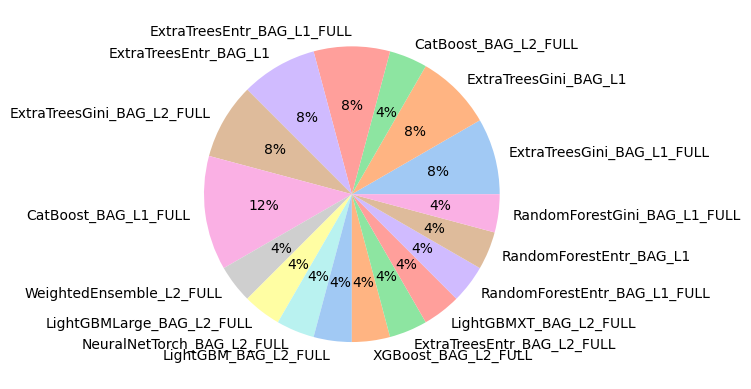

In [11]:
colors = sns.color_palette('pastel')[0:20]
plt.pie(list(best_model.values()), labels=list(best_model), colors = colors, autopct='%.0f%%')

In [12]:
best_features

{'Feature 1': 8,
 'Feature 3': 7,
 'Feature 4': 1,
 'Feature 5': 2,
 'Feature 6': 1,
 'Feature 2': 5}

([<matplotlib.patches.Wedge at 0x7f8b6c192ed0>,
 [Text(0.5499999702695115, 0.9526279613277875, 'Feature 1'),
  Text(-1.0905893519921306, 0.14357877740594205, 'Feature 3'),
  Text(-0.6696375685051341, -0.8726886769326917, 'Feature 4'),
  Text(-0.2847009330327477, -1.0625184133605794, 'Feature 5'),
  Text(0.1435788412236565, -1.090589343590369, 'Feature 6'),
  Text(0.8726886847696911, -0.6696375582917575, 'Feature 2')],
 [Text(0.2999999837833699, 0.5196152516333385, '33%'),
  Text(-0.5948669192684347, 0.07831569676687748, '29%'),
  Text(-0.36525685554825493, -0.47601200559964996, '4%'),
  Text(-0.15529141801786234, -0.5795554981966796, '8%'),
  Text(0.0783157315765399, -0.5948669146856558, '4%'),
  Text(0.4760120098743769, -0.3652568499773222, '21%')])

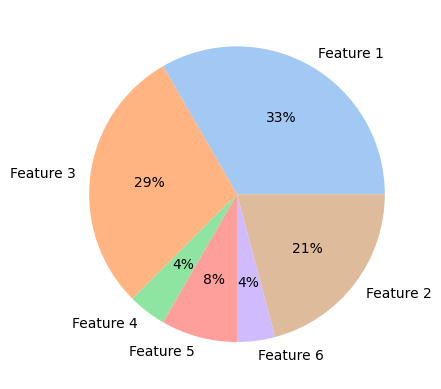

In [13]:
plt.pie(list(best_features.values()), labels=list(best_features), colors = colors, autopct='%.0f%%')